# Predicting Stellar Class — アンサンブルモデル

天体データから `GALAXY` / `QSO` / `STAR` の3クラスを予測する。

- **評価指標**: Balanced Accuracy
- **モデル**: LightGBM + XGBoost + CatBoost のアンサンブル(確率平均)
- **不均衡対策**: クラスバランス化したサンプル重みで学習
- **検証**: StratifiedKFold 3-fold のOOF評価

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from pathlib import Path

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

SEED = 42
N_FOLDS = 5
SEED_LIST = [42, 52, 62]
EXP_OUTPUT_DIR = Path(".")
EXP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_DIR = EXP_OUTPUT_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_FILENAME = "submission-007.csv"
TEST_PROBA_FILENAME = "test_proba-007.csv"
TEST_PROBA_NPY_FILENAME = "test_proba-007.npy"

train = pd.read_csv("../../data/train.csv")
test = pd.read_csv("../../data/test.csv")
sample_sub = pd.read_csv("../../data/sample_submission.csv")

print(train.shape, test.shape)
train.head()


(577347, 12) (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## 1. 簡単なEDA

クラス分布と、判別に効きそうな `redshift` の分布を確認する。

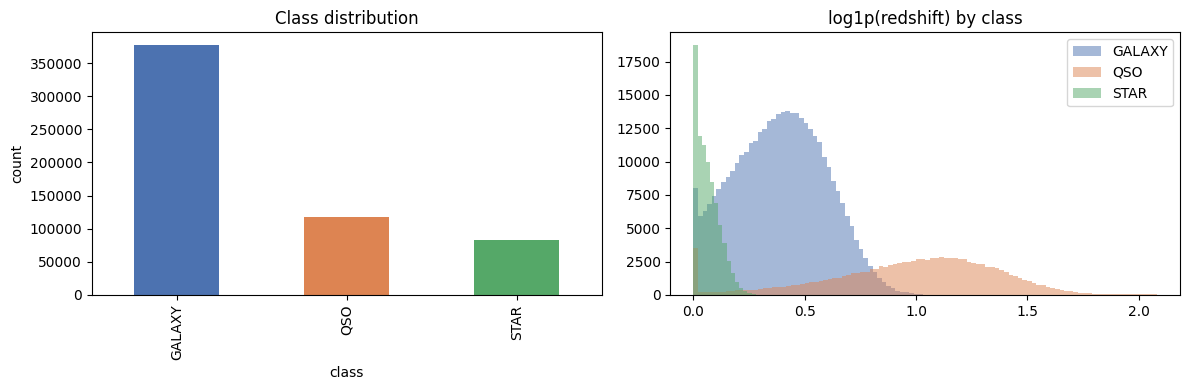

           count      mean       std       min       25%       50%       75%  \
class                                                                          
GALAXY  377480.0  0.509026  0.309139 -0.009934  0.267017  0.481960  0.715023   
QSO     117143.0  1.875641  1.069731  0.000100  1.131805  1.798886  2.506401   
STAR     82724.0  0.068115  0.064476 -0.009970  0.021884  0.056492  0.102069   

             max  
class             
GALAXY  6.860273  
QSO     7.010780  
STAR    5.445217  


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train["class"].value_counts().plot.bar(ax=axes[0], color=["#4c72b0", "#dd8452", "#55a868"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("count")

for cls, color in zip(["GALAXY", "QSO", "STAR"], ["#4c72b0", "#dd8452", "#55a868"]):
    subset = train.loc[train["class"] == cls, "redshift"]
    axes[1].hist(np.log1p(subset.clip(lower=0)), bins=100, alpha=0.5, label=cls, color=color)
axes[1].set_title("log1p(redshift) by class")
axes[1].legend()

plt.tight_layout()
plt.show()

print(train.groupby("class")["redshift"].describe())

## 2. 特徴量エンジニアリング

- **色指数 (color index)**: 隣接バンドの等級差(`u-g`, `g-r`, `r-i`, `i-z`)は天体分類の定番特徴量
- 広いバンド間の差(`u-r`, `g-i`, `u-z`)も追加
- `redshift` は分布が裾広がりなので `log1p` 変換版も追加
- カテゴリ列(`spectral_type`, `galaxy_population`)はラベルエンコードし、LightGBM / CatBoost にはカテゴリとして渡す
- `alpha` / `delta`(天球座標)は本来クラスと無関係のはずだが、念のため残してモデルに判断させる

In [3]:
CAT_COLS = ["spectral_type", "galaxy_population"]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # 色指数(隣接バンド)
    out["u_g"] = out["u"] - out["g"]
    out["g_r"] = out["g"] - out["r"]
    out["r_i"] = out["r"] - out["i"]
    out["i_z"] = out["i"] - out["z"]
    # 広いバンド間
    out["u_r"] = out["u"] - out["r"]
    out["g_i"] = out["g"] - out["i"]
    out["u_z"] = out["u"] - out["z"]

    out["redshift_log1p"] = np.log1p(out["redshift"].clip(lower=0))

    return out


# カテゴリ列はtrain/test共通のエンコーダで数値化
cat_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    cat_encoders[col] = le

train_fe = build_features(train)
test_fe = build_features(test)
for col, le in cat_encoders.items():
    train_fe[col] = le.transform(train_fe[col])
    test_fe[col] = le.transform(test_fe[col])

FEATURES = [c for c in train_fe.columns if c not in ("id", "class")]

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(train_fe["class"])
X = train_fe[FEATURES]
X_test = test_fe[FEATURES]

# balanced accuracy向けにクラスバランス化した重み
sample_weight = compute_sample_weight("balanced", y)

print("features:", FEATURES)
print("classes:", list(target_encoder.classes_))

features: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'u_z', 'redshift_log1p']
classes: ['GALAXY', 'QSO', 'STAR']


In [4]:
# --- Feature override: galactic coordinates + trig features ---
def equatorial_to_galactic(alpha_deg: np.ndarray, delta_deg: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    # J2000 constants
    ra_ngp = np.deg2rad(192.85948)
    dec_ngp = np.deg2rad(27.12825)
    l_omega = np.deg2rad(32.93192)

    ra = np.deg2rad(alpha_deg)
    dec = np.deg2rad(delta_deg)

    sin_b = np.sin(dec) * np.sin(dec_ngp) + np.cos(dec) * np.cos(dec_ngp) * np.cos(ra - ra_ngp)
    b = np.arcsin(np.clip(sin_b, -1.0, 1.0))

    y_part = np.cos(dec) * np.sin(ra - ra_ngp)
    x_part = np.sin(dec) * np.cos(dec_ngp) - np.cos(dec) * np.sin(dec_ngp) * np.cos(ra - ra_ngp)
    l = np.arctan2(y_part, x_part) + l_omega
    l = np.mod(l, 2.0 * np.pi)

    return np.rad2deg(l), np.rad2deg(b)


def add_trig_pair(out: pd.DataFrame, col: str) -> None:
    rad = np.deg2rad(out[col].values)
    out[f"{col}_sin"] = np.sin(rad)
    out[f"{col}_cos"] = np.cos(rad)


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # color indices
    out["u_g"] = out["u"] - out["g"]
    out["g_r"] = out["g"] - out["r"]
    out["r_i"] = out["r"] - out["i"]
    out["i_z"] = out["i"] - out["z"]
    out["u_r"] = out["u"] - out["r"]
    out["g_i"] = out["g"] - out["i"]
    out["u_z"] = out["u"] - out["z"]

    out["redshift_log1p"] = np.log1p(out["redshift"].clip(lower=0))

    # galactic coords
    l_deg, b_deg = equatorial_to_galactic(out["alpha"].values, out["delta"].values)
    out["l"] = l_deg
    out["b"] = b_deg

    # periodic transforms
    for col in ["alpha", "delta", "l", "b"]:
        add_trig_pair(out, col)

    return out


# Rebuild encoded features with new build_features definition
cat_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    le.fit(pd.concat([train[col], test[col]]))
    cat_encoders[col] = le

train_fe = build_features(train)
test_fe = build_features(test)
for col, le in cat_encoders.items():
    train_fe[col] = le.transform(train_fe[col])
    test_fe[col] = le.transform(test_fe[col])

FEATURES = [c for c in train_fe.columns if c not in ("id", "class")]

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(train_fe["class"])
X = train_fe[FEATURES]
X_test = test_fe[FEATURES]

sample_weight = compute_sample_weight("balanced", y)

print("features (overridden):", FEATURES)
print("n_features:", len(FEATURES))

features (overridden): ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z', 'u_r', 'g_i', 'u_z', 'redshift_log1p', 'l', 'b', 'alpha_sin', 'alpha_cos', 'delta_sin', 'delta_cos', 'l_sin', 'l_cos', 'b_sin', 'b_cos']
n_features: 28


## 3. 学習(5-fold CV + 20モデル)

In [5]:
from catboost import Pool

N_CLASSES = len(target_encoder.classes_)

MODEL_SPECS = [
    {"name": "lgbm_1", "family": "lgbm", "params": {"n_estimators": 1800, "learning_rate": 0.05, "num_leaves": 127, "colsample_bytree": 0.8, "subsample": 0.8, "min_child_samples": 30}},
    {"name": "lgbm_2", "family": "lgbm", "params": {"n_estimators": 2200, "learning_rate": 0.04, "num_leaves": 255, "colsample_bytree": 0.9, "subsample": 0.9, "min_child_samples": 40}},
    {"name": "lgbm_3", "family": "lgbm", "params": {"n_estimators": 1600, "learning_rate": 0.06, "num_leaves": 63, "colsample_bytree": 0.7, "subsample": 0.8, "min_child_samples": 60}},
    {"name": "lgbm_4", "family": "lgbm", "params": {"n_estimators": 2600, "learning_rate": 0.03, "num_leaves": 191, "colsample_bytree": 0.85, "subsample": 0.9, "min_child_samples": 25}},
    {"name": "lgbm_goss", "family": "lgbm", "params": {"n_estimators": 2000, "learning_rate": 0.05, "num_leaves": 127, "boosting_type": "goss", "top_rate": 0.2, "other_rate": 0.1, "min_child_samples": 30}},
    {"name": "xgb_1", "family": "xgb", "params": {"n_estimators": 1800, "learning_rate": 0.05, "max_depth": 8, "colsample_bytree": 0.8, "subsample": 0.8, "min_child_weight": 1}},
    {"name": "xgb_2", "family": "xgb", "params": {"n_estimators": 2200, "learning_rate": 0.04, "max_depth": 10, "colsample_bytree": 0.9, "subsample": 0.9, "min_child_weight": 2}},
    {"name": "xgb_3", "family": "xgb", "params": {"n_estimators": 1500, "learning_rate": 0.06, "max_depth": 6, "colsample_bytree": 0.7, "subsample": 0.8, "gamma": 0.2}},
    {"name": "xgb_4", "family": "xgb", "params": {"n_estimators": 2600, "learning_rate": 0.03, "max_depth": 9, "colsample_bytree": 0.85, "subsample": 0.9, "reg_lambda": 2.0}},
    {"name": "cat_1", "family": "cat", "params": {"iterations": 2000, "learning_rate": 0.08, "depth": 8, "l2_leaf_reg": 3.0}},
    {"name": "cat_2", "family": "cat", "params": {"iterations": 2500, "learning_rate": 0.05, "depth": 10, "l2_leaf_reg": 5.0}},
    {"name": "cat_3", "family": "cat", "params": {"iterations": 1600, "learning_rate": 0.10, "depth": 6, "random_strength": 2.0}},
    {"name": "et_1", "family": "et", "params": {"n_estimators": 700, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"}},
    {"name": "rf_1", "family": "rf", "params": {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt", "class_weight": "balanced_subsample"}},
    {"name": "hgb_1", "family": "hgb", "params": {"learning_rate": 0.05, "max_iter": 600, "max_depth": 8, "min_samples_leaf": 20}},
    {"name": "hgb_2", "family": "hgb", "params": {"learning_rate": 0.03, "max_iter": 900, "max_depth": 10, "min_samples_leaf": 30}},
    {"name": "logreg_1", "family": "logreg", "params": {"C": 2.0, "max_iter": 4000}},
    {"name": "logreg_2", "family": "logreg", "params": {"C": 0.8, "max_iter": 5000}},
    {"name": "knn_1", "family": "knn", "params": {"n_neighbors": 35, "weights": "distance"}},
    {"name": "knn_2", "family": "knn", "params": {"n_neighbors": 55, "weights": "distance"}},
]

MODEL_NAMES = [m["name"] for m in MODEL_SPECS]
MODEL_MAP = {m["name"]: m for m in MODEL_SPECS}

oof = {m: np.zeros((len(X), N_CLASSES)) for m in MODEL_NAMES}
pred_test = {m: np.zeros((len(X_test), N_CLASSES)) for m in MODEL_NAMES}
oof_fold = {m: [] for m in MODEL_NAMES}
pred_test_fold = {m: [] for m in MODEL_NAMES}
va_indices = []
y_valid_folds = []

cat_feature_idx = [FEATURES.index(c) for c in CAT_COLS]

for seed in SEED_LIST:
    print(f"=== seed {seed} ===")
    oof_seed = {m: np.zeros((len(X), N_CLASSES)) for m in MODEL_NAMES}
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        w_tr, w_va = sample_weight[tr_idx], sample_weight[va_idx]

        for model_name in MODEL_NAMES:
            spec = MODEL_MAP[model_name]
            family = spec["family"]
            p = dict(spec["params"])

            if family == "lgbm":
                model = lgb.LGBMClassifier(
                    objective="multiclass",
                    random_state=seed,
                    n_jobs=-1,
                    verbosity=-1,
                    **p,
                )
                model.fit(
                    X_tr, y_tr,
                    sample_weight=w_tr,
                    eval_set=[(X_va, y_va)],
                    eval_sample_weight=[w_va],
                    categorical_feature=CAT_COLS,
                    callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
                )
            elif family == "xgb":
                model = xgb.XGBClassifier(
                    objective="multi:softprob",
                    tree_method="hist",
                    device="cuda",
                    early_stopping_rounds=80,
                    random_state=seed,
                    n_jobs=-1,
                    verbosity=0,
                    **p,
                )
                model.fit(
                    X_tr, y_tr,
                    sample_weight=w_tr,
                    eval_set=[(X_va, y_va)],
                    sample_weight_eval_set=[w_va],
                    verbose=False,
                )
            elif family == "cat":
                model = CatBoostClassifier(
                    loss_function="MultiClass",
                    random_seed=seed,
                    early_stopping_rounds=80,
                    task_type="GPU",
                    devices="0",
                    verbose=0,
                    **p,
                )
                model.fit(
                    Pool(X_tr, y_tr, weight=w_tr, cat_features=cat_feature_idx),
                    eval_set=Pool(X_va, y_va, weight=w_va, cat_features=cat_feature_idx),
                )
            elif family == "et":
                model = ExtraTreesClassifier(random_state=seed, n_jobs=-1, **p)
                model.fit(X_tr, y_tr, sample_weight=w_tr)
            elif family == "rf":
                model = RandomForestClassifier(random_state=seed, n_jobs=-1, **p)
                model.fit(X_tr, y_tr, sample_weight=w_tr)
            elif family == "hgb":
                model = HistGradientBoostingClassifier(random_state=seed, **p)
                model.fit(X_tr, y_tr, sample_weight=w_tr)
            elif family == "logreg":
                model = LogisticRegression(
                    multi_class="multinomial",
                    class_weight="balanced",
                    solver="lbfgs",
                    random_state=seed,
                    n_jobs=-1,
                    **p,
                )
                model.fit(X_tr, y_tr, sample_weight=w_tr)
            elif family == "knn":
                model = KNeighborsClassifier(**p)
                model.fit(X_tr, y_tr)
            else:
                raise ValueError(f"unknown family: {family}")

            va_pred = model.predict_proba(X_va)
            te_pred = model.predict_proba(X_test)

            oof_seed[model_name][va_idx] = va_pred
            pred_test[model_name] += te_pred / (N_FOLDS * len(SEED_LIST))
            oof_fold[model_name].append(va_pred)
            pred_test_fold[model_name].append(te_pred)

        va_indices.append(va_idx)
        y_valid_folds.append(y_va)

        fold_scores = {m: balanced_accuracy_score(y_va, oof_seed[m][va_idx].argmax(axis=1)) for m in MODEL_NAMES}
        top5 = sorted(fold_scores.items(), key=lambda x: x[1], reverse=True)[:5]
        print(f"seed {seed} fold {fold} top5:", ", ".join(f"{m}={s:.5f}" for m, s in top5))

    for m in MODEL_NAMES:
        oof[m] += oof_seed[m] / len(SEED_LIST)

for m in MODEL_NAMES:
    print(f"OOF balanced accuracy [{m}] seed-avg: {balanced_accuracy_score(y, oof[m].argmax(axis=1)):.5f}")

np.savez_compressed(
    ARTIFACTS_DIR / "pred_test.npz",
    **{m: pred_test[m] for m in MODEL_NAMES},
)
np.savez_compressed(
    ARTIFACTS_DIR / "oof.npz",
    **{m: oof[m] for m in MODEL_NAMES},
)
np.save(ARTIFACTS_DIR / "model_names.npy", np.array(MODEL_NAMES, dtype=object))
print(f"saved artifacts: {ARTIFACTS_DIR}")


=== seed 42 ===


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


seed 42 fold 0 top5: xgb_3=0.96682, lgbm_3=0.96636, xgb_1=0.96617, lgbm_goss=0.96617, lgbm_1=0.96597


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


...

C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


seed 62 fold 4 top5: xgb_3=0.96651, xgb_1=0.96637, lgbm_3=0.96636, lgbm_1=0.96628, lgbm_goss=0.96611
OOF balanced accuracy [lgbm_1] seed-avg: 0.96605
OOF balanced accuracy [lgbm_2] seed-avg: 0.96589
OOF balanced accuracy [lgbm_3] seed-avg: 0.96622
OOF balanced accuracy [lgbm_4] seed-avg: 0.96589
OOF balanced accuracy [lgbm_goss] seed-avg: 0.96599
OOF balanced accuracy [xgb_1] seed-avg: 0.96604
OOF balanced accuracy [xgb_2] seed-avg: 0.96530
OOF balanced accuracy [xgb_3] seed-avg: 0.96650
OOF balanced accuracy [xgb_4] seed-avg: 0.96578
OOF balanced accuracy [cat_1] seed-avg: 0.96458
OOF balanced accuracy [cat_2] seed-avg: 0.96400
OOF balanced accuracy [cat_3] seed-avg: 0.96477
OOF balanced accuracy [et_1] seed-avg: 0.95352
OOF balanced accuracy [rf_1] seed-avg: 0.95332
OOF balanced accuracy [hgb_1] seed-avg: 0.96334


OOF balanced accuracy [hgb_2] seed-avg: 0.96485
OOF balanced accuracy [logreg_1] seed-avg: 0.92012
OOF balanced accuracy [logreg_2] seed-avg: 0.92064
OOF balanced accuracy [knn_1] seed-avg: 0.86285
OOF balanced accuracy [knn_2] seed-avg: 0.85127


saved artifacts: artifacts


## 4. アンサンブル

6モデルの予測確率を重み付き平均する。重みはOOFのbalanced accuracyが最大になる組み合わせをグリッドサーチで決める。

n_models: 20
top10 model OOF scores: [('xgb_3', 0.9664979740162364), ('lgbm_3', 0.966217539891601), ('lgbm_1', 0.9660474301590559), ('xgb_1', 0.9660446379500401), ('lgbm_goss', 0.9659863471898097), ('lgbm_4', 0.9658914175841709), ('lgbm_2', 0.9658883668146055), ('xgb_4', 0.965778254925949), ('xgb_2', 0.9653015744704904), ('hgb_2', 0.9648523132762703)]
ensemble OOF balanced accuracy (base) = 0.96576


fold 0 best bias = [-0.06, 0.05000000000000002, 0.060000000000000026], score = 0.96654


fold 1 best bias = [-0.06, 0.060000000000000026, 0.05000000000000002], score = 0.96623


fold 2 best bias = [-0.06, -0.009999999999999988, 0.060000000000000026], score = 0.96536


fold 3 best bias = [-0.049999999999999996, -0.06, 0.05000000000000002], score = 0.96547


fold 4 best bias = [-0.06, -0.01999999999999999, 0.04000000000000002], score = 0.96655


ensemble OOF balanced accuracy (bias-corrected) = 0.96595
mean fold bias: [-0.059333333333333356, 0.012666666666666684, 0.05533333333333337]


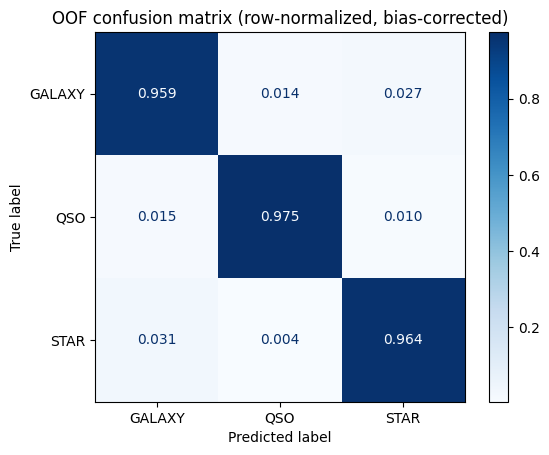

In [6]:
from itertools import product

# Fast ensemble for many models:
# 1) score each model's OOF
model_scores = {m: balanced_accuracy_score(y, oof[m].argmax(axis=1)) for m in MODEL_NAMES}
score_sum = sum(max(v, 1e-6) for v in model_scores.values())

# 2) normalize to weights (acts as a strong baseline with 20 models)
best_weights = tuple(max(model_scores[m], 1e-6) / score_sum for m in MODEL_NAMES)
best_score = balanced_accuracy_score(y, sum(w * oof[m] for w, m in zip(best_weights, MODEL_NAMES)).argmax(axis=1))

print("n_models:", len(MODEL_NAMES))
print("top10 model OOF scores:", sorted(model_scores.items(), key=lambda x: x[1], reverse=True)[:10])
print(f"ensemble OOF balanced accuracy (base) = {best_score:.5f}")

def find_best_bias(log_proba, y_true, bias_grid):
    best_bias = np.zeros(log_proba.shape[1])
    best_score_local = -1.0
    for bias in product(bias_grid, repeat=log_proba.shape[1]):
        bias = np.array(bias)
        pred_tmp = (log_proba + bias).argmax(axis=1)
        s = balanced_accuracy_score(y_true, pred_tmp)
        if s > best_score_local:
            best_score_local = s
            best_bias = bias.copy()
    return best_bias, best_score_local

def apply_log_bias_to_proba(proba, bias):
    adj = np.exp(np.log(np.clip(proba, 1e-15, 1.0)) + bias)
    return adj / adj.sum(axis=1, keepdims=True)

oof_blend_base = sum(w * oof[m] for w, m in zip(best_weights, MODEL_NAMES))
bias_grid = np.arange(-0.06, 0.061, 0.01)
fold_biases = []
oof_blend_bias = np.zeros((len(X), N_CLASSES))
test_blend_bias = np.zeros((len(X_test), N_CLASSES))
n_valid_folds = len(va_indices)

for fold in range(n_valid_folds):
    va_idx = va_indices[fold]
    y_va = y_valid_folds[fold]
    va_blend = sum(w * oof_fold[m][fold] for w, m in zip(best_weights, MODEL_NAMES))
    test_blend_fold = sum(w * pred_test_fold[m][fold] for w, m in zip(best_weights, MODEL_NAMES))
    best_bias, best_score_fold = find_best_bias(np.log(np.clip(va_blend, 1e-15, 1.0)), y_va, bias_grid)
    fold_biases.append(best_bias)
    oof_blend_bias[va_idx] = apply_log_bias_to_proba(va_blend, best_bias)
    test_blend_bias += apply_log_bias_to_proba(test_blend_fold, best_bias) / n_valid_folds
    if fold < 5:
        print(f"fold {fold} best bias = {best_bias.tolist()}, score = {best_score_fold:.5f}")

oof_pred = oof_blend_bias.argmax(axis=1)
score_bias = balanced_accuracy_score(y, oof_pred)
print(f"ensemble OOF balanced accuracy (bias-corrected) = {score_bias:.5f}")
print("mean fold bias:", np.mean(np.stack(fold_biases), axis=0).tolist())

test_blend = test_blend_bias
cm = confusion_matrix(y, oof_pred, normalize="true")
disp = ConfusionMatrixDisplay(cm, display_labels=target_encoder.classes_)
disp.plot(cmap="Blues", values_format=".3f")
plt.title("OOF confusion matrix (row-normalized, bias-corrected)")
plt.show()


## 5. スタッキング（OOFメタ学習）

6モデルのOOF確率を特徴量として、2層目のロジスティック回帰を学習する。
メタ層もfoldで学習し、OOFとtest予測を作る。

## 6. 提出ファイル作成

スタッキングで得た `test_blend` から最終クラスと test 確率を出力する。
- `submission-007.csv` — 提出用ラベル
- `test_proba-007.csv` / `test_proba-007.npy` — STAR-tuned 後のクラス確率（後処理・ブレンド用）

C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\nihei\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


stacking OOF balanced accuracy (meta=LGBM, raw) = 0.96729
best STAR weight = 1.15
stacking OOF balanced accuracy (STAR-tuned) = 0.96743


saved: test_proba-007.csv
saved: test_proba-007.npy


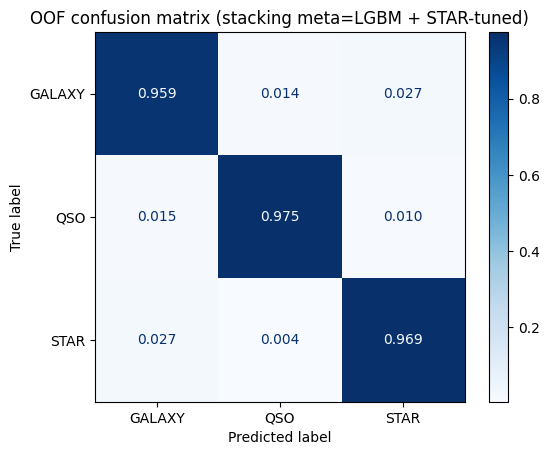

saved: submission-007.csv
class
GALAXY    156970
QSO        51266
STAR       39199
Name: count, dtype: int64


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY


In [7]:
# OOF probabilities -> meta features
meta_features = np.concatenate([oof[m] for m in MODEL_NAMES], axis=1)
meta_test_features = np.concatenate([pred_test[m] for m in MODEL_NAMES], axis=1)

# meta CV with LightGBM
meta_oof = np.zeros((len(X), N_CLASSES))
meta_test = np.zeros((len(X_test), N_CLASSES))

meta_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED + 999)
for fold, (tr_idx, va_idx) in enumerate(meta_skf.split(meta_features, y)):
    X_meta_tr, X_meta_va = meta_features[tr_idx], meta_features[va_idx]
    y_meta_tr, y_meta_va = y[tr_idx], y[va_idx]
    w_meta_tr = compute_sample_weight("balanced", y_meta_tr)

    meta_model = lgb.LGBMClassifier(
        objective="multiclass",
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=SEED + 999 + fold,
        n_jobs=-1,
        verbosity=-1,
    )
    meta_model.fit(
        X_meta_tr,
        y_meta_tr,
        sample_weight=w_meta_tr,
        eval_set=[(X_meta_va, y_meta_va)],
        callbacks=[lgb.early_stopping(80, verbose=False), lgb.log_evaluation(0)],
    )

    meta_oof[va_idx] = meta_model.predict_proba(X_meta_va)
    meta_test += meta_model.predict_proba(meta_test_features) / N_FOLDS

meta_score_raw = balanced_accuracy_score(y, meta_oof.argmax(axis=1))
print(f"stacking OOF balanced accuracy (meta=LGBM, raw) = {meta_score_raw:.5f}")

# STAR-first tuning (EXP005-lite): boost STAR posterior only
star_idx = int(np.where(target_encoder.classes_ == "STAR")[0][0])
star_grid = np.arange(1.00, 1.51, 0.05)
best_star_w, best_star_score = 1.0, -1.0
for ws in star_grid:
    w = np.ones(N_CLASSES)
    w[star_idx] = ws
    pred_tmp = (meta_oof * w).argmax(axis=1)
    s = balanced_accuracy_score(y, pred_tmp)
    if s > best_star_score:
        best_star_score = s
        best_star_w = float(ws)

star_w = np.ones(N_CLASSES)
star_w[star_idx] = best_star_w
meta_oof_star = meta_oof * star_w
meta_test_star = meta_test * star_w
meta_oof_star = meta_oof_star / meta_oof_star.sum(axis=1, keepdims=True)
meta_test_star = meta_test_star / meta_test_star.sum(axis=1, keepdims=True)

meta_score_star = balanced_accuracy_score(y, meta_oof_star.argmax(axis=1))
print(f"best STAR weight = {best_star_w:.2f}")
print(f"stacking OOF balanced accuracy (STAR-tuned) = {meta_score_star:.5f}")

# Use STAR-tuned output for submission
test_blend = meta_test_star

class_names = list(target_encoder.classes_)
proba_df = pd.DataFrame({"id": test_fe["id"].to_numpy()})
for i, cls in enumerate(class_names):
    proba_df[f"proba_{cls}"] = test_blend[:, i]
proba_csv_path = EXP_OUTPUT_DIR / TEST_PROBA_FILENAME
proba_npy_path = EXP_OUTPUT_DIR / TEST_PROBA_NPY_FILENAME
proba_df.to_csv(proba_csv_path, index=False)
np.save(proba_npy_path, test_blend.astype(np.float32))
print(f"saved: {proba_csv_path}")
print(f"saved: {proba_npy_path}")

cm_stack = confusion_matrix(y, meta_oof_star.argmax(axis=1), normalize="true")
disp_stack = ConfusionMatrixDisplay(cm_stack, display_labels=target_encoder.classes_)
disp_stack.plot(cmap="Blues", values_format=".3f")
plt.title("OOF confusion matrix (stacking meta=LGBM + STAR-tuned)")
plt.show()

test_pred = target_encoder.inverse_transform(test_blend.argmax(axis=1))

submission = pd.DataFrame({"id": test_fe["id"], "class": test_pred})
assert (submission["id"].values == sample_sub["id"].values).all()
submission_path = EXP_OUTPUT_DIR / SUBMISSION_FILENAME
submission.to_csv(submission_path, index=False)
print(f"saved: {submission_path}")

print(submission["class"].value_counts())
submission.head()
